### Weekly Natural Gas Monitor — Next-Quarter Monte Carlo

> **Are U.S. natural gas conditions tightening or loosening over the next quarter, and is the move expected, elevated, or extreme?**

Core outputs:
- Historical storage and balance monitor
- Supply vs demand diagnostics
- Balance chart
- Next-quarter Monte Carlo forecast with storage and balance bands
- Energy Atlas-style signal table for weekly reporting

Modeling note: this version treats forward output as a **physical market regime monitor**, not a Henry Hub point forecast.


In [26]:
# Imports

import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from calibration import (
    calibrate_reference_scenario,
    latest_weekly_storage_release,
    weekly_storage_history,
    weekly_price_history,
)
from enhanced_gas_model import (
    augment_scenario_with_seasonal_limits,
    build_weekly_comparison,
    build_weekly_history_panel,
    build_weekly_market_signal,
    fit_price_model,
    rolling_origin_validation_weekly,
    score_weekly_comparison,
    simulate_weekly_forward_scenario,
    simulate_weekly_historical_backtest,
    summarize_weekly_monte_carlo,
)

from weather_data import (
    build_region_weather_daily,
    daily_to_monthly_weather,
    daily_to_weekly_weather,
    estimate_weather_demand_sensitivity,
    merge_weather_into_monthly_panel,
    merge_weather_into_weekly_panel,
)


## 1. Report configuration

In [27]:
# -----------------------------
# Weekly report settings
# -----------------------------

CALIBRATION_START = "2018-01"
CALIBRATION_END = None

REPORT_LOOKBACK_WEEKS = 156
FORECAST_MONTHS = 3
FORECAST_WEEKS = 13
N_MONTE_CARLO = 500
MC_SEED = 42

REPORT_TITLE = "Natural Gas Weekly Monitor"
REPORT_DATE = pd.Timestamp.today().normalize()

# Forward Monte Carlo scenario assumptions
# These are broad scenario assumptions, not one-month hand tuning.
BASE_FORWARD = {
    "lng_export_pct": 0.00,
    "demand_sigma": 0.00,
    "supply_pct": 0.00,
    "pipeline_capacity_pct": 0.00,
}

COLD_LNG_FORWARD = {
    "lng_export_pct": 0.15,
    "demand_sigma": 1.00,
    "supply_pct": 0.00,
    "pipeline_capacity_pct": 0.00,
}

LOOSE_SUPPLY_FORWARD = {
    "lng_export_pct": 0.00,
    "demand_sigma": -0.50,
    "supply_pct": 0.03,
    "pipeline_capacity_pct": 0.00,
}

plt.rcParams["figure.figsize"] = (12, 5)


### Retrieve region weather history


In [28]:
weather_daily = build_region_weather_daily(
    stations_csv="major_airports_by_state_ghcnd.csv",
    region="all",
    start="2018-01-01",
    cache_dir="data/raw/noaa/stations",
)

weather_monthly = daily_to_monthly_weather(weather_daily)
weather_weekly = daily_to_weekly_weather(weather_daily)

print("Weekly weather history:")
display(weather_weekly.tail())


Weekly weather history:


,region_id,date,hdd,cdd,tavg_f,tavg_c,n_weather_days,avg_stations_used
2175,west,2026-04-10,36.150,0.0,59.835714,15.464286,7,15.857143
2176,west,2026-04-17,59.325,0.0,56.525000,13.625000,7,16.000000
2177,west,2026-04-24,40.290,0.0,59.244286,15.135714,7,16.000000
2178,west,2026-05-01,46.500,0.0,58.357143,14.642857,7,15.857143
2179,west,2026-05-08,4.530,0.0,62.735000,17.075000,2,16.000000


## 2. Simulator core

The simulator has two modes:

### Historical backtest mode
Uses weekly EIA storage and Henry Hub history, with monthly EIA production, demand, and LNG exports apportioned across week-ending dates for balance diagnostics.

### Forward simulation mode
Uses calibrated baseline parameters and random demand/weather variation to simulate next-quarter paths.

Price is represented as a fitted market pressure proxy, not an exact Henry Hub point forecast.


In [29]:
DAYS_PER_MONTH = 30


class GasMarket:
    """
    Monthly natural gas balance simulator.

    Core chain:
        supply -> delivered supply -> demand -> storage change -> price pressure

    This model estimates directional market pressure, not exact Henry Hub prices.
    """

    def __init__(self, scenario):
        self.scenario = scenario

        self.storage = float(scenario.get("initial_storage", 3000.0))
        self.storage_capacity = float(scenario.get("storage_capacity", 4200.0))
        self.max_injection = float(scenario.get("max_injection", 300.0))
        self.max_withdrawal = float(scenario.get("max_withdrawal", 500.0))

        self.base_price = float(scenario.get("base_price", 3.00))
        self.price = self.base_price

        self.history = []

    def _historical_row(self, month):
        if not self.scenario.get("use_historical_drivers", False):
            return None
        panel = self.scenario.get("historical_panel")
        if panel is None or month >= len(panel):
            return None
        return panel.iloc[month]


    def supply(self, month):
        """
        Production / supply side.
    
        Historical mode: uses observed production (no noise unless explicitly enabled).
        Forward mode: uses base supply + structural shift + persistent noise.
        """
        row = self._historical_row(month)
    
        # --- 1. Base supply ---
        if row is not None and "production_bcf" in row:
            base_supply = float(row["production_bcf"])
            use_noise = bool(self.scenario.get("historical_supply_noise", False))
        else:
            base_supply = float(self.scenario.get("base_supply", 3100.0))
            use_noise = True
    
        # --- 2. Structural shift (slow-moving) ---
        supply_shift_pct = float(self.scenario.get("supply_shift_pct", 0.0))
        base_supply *= (1.0 + supply_shift_pct)
    
        # --- 3. Deterministic shock (e.g., freeze-off, outage) ---
        shock = float(self.scenario.get("supply_shock", 0.0))
    
        # --- 4. Stochastic noise (persistent, not white noise) ---
        supply_noise = 0.0
    
        if use_noise:
            noise_std_bcf = float(self.scenario.get("supply_noise_bcf", 0.0))
            noise_std_pct = float(self.scenario.get("supply_noise_pct", 0.0))
    
            # Persistent noise (AR(1)-like)
            prev_noise = getattr(self, "_supply_noise_state", 0.0)
            persistence = float(self.scenario.get("supply_noise_persistence", 0.6))
    
            new_noise = 0.0
            if noise_std_bcf > 0:
                new_noise += np.random.normal(0.0, noise_std_bcf)
            if noise_std_pct > 0:
                new_noise += np.random.normal(0.0, abs(base_supply) * noise_std_pct)
    
            supply_noise = persistence * prev_noise + (1 - persistence) * new_noise
            self._supply_noise_state = supply_noise
    
        # --- 5. Final supply ---
        return max(0.0, base_supply + shock + supply_noise)

    def demand(self, month):
        """
        Demand side.

        Priority order:
        1. Weather-driven demand when use_weather_demand=True and HDD/CDD are present.
        2. Historical EIA demand replay.
        3. Seasonal fallback with stochastic residual.

        The returned value is total call on supply:
            domestic demand + LNG exports
        """
        row = self._historical_row(month)
        use_weather = bool(self.scenario.get("use_weather_demand", False))

        if row is not None and use_weather and "hdd" in row and "cdd" in row:

            hdd_sens = float(self.scenario.get("hdd_sensitivity", 0.0)) * float(self.scenario.get("hdd_sensitivity_scale", 1.0))
            cdd_sens = float(self.scenario.get("cdd_sensitivity", 0.0)) * float(self.scenario.get("cdd_sensitivity_scale", 1.0))
            
            cdd_multiplier = float(self.scenario.get("cdd_power_multiplier", 1.2))
            
            hdd = float(row["hdd"])
            cdd = float(row["cdd"])
            
            domestic_demand = (
                float(self.scenario.get("weather_base_demand", self.scenario.get("base_demand", 2900.0)))
                + hdd_sens * hdd
                + cdd_sens * cdd_multiplier * cdd
            )

            
            # Minor realism update: residual demand uncertainty not explained by HDD/CDD.
            demand_noise_bcf = float(self.scenario.get("demand_noise_bcf", 0.0))
            if demand_noise_bcf > 0:
                domestic_demand += np.random.normal(0.0, demand_noise_bcf)

        elif row is not None and "demand_bcf" in row:
            # Historical replay uses actual EIA domestic demand.
            domestic_demand = float(row["demand_bcf"])

        else:
            base_demand = float(self.scenario.get("base_demand", 2900.0))
            seasonal_factors = self.scenario.get(
                "seasonal_factors",
                [1.35, 1.25, 1.05, 0.85, 0.75, 0.80, 0.95, 1.00, 0.85, 0.90, 1.05, 1.30],
            )
            raw_factor = float(seasonal_factors[month % 12])
            seasonal_strength = float(self.scenario.get("seasonal_strength", 1.0))
            seasonal_factor = 1.0 + seasonal_strength * (raw_factor - 1.0)

            weather_shock = random.gauss(
                float(self.scenario.get("weather_mean", 0.0)),
                float(self.scenario.get("weather_volatility", 80.0))
                * float(self.scenario.get("weather_volatility_scale", 1.0)),
            )
            domestic_demand = base_demand * seasonal_factor + weather_shock

        if row is not None and "lng_exports_bcf" in row:
            lng_exports = float(row["lng_exports_bcf"])
        else:
            lng_exports = float(self.scenario.get("lng_exports", 400.0))

        return max(0.0, domestic_demand + lng_exports)

    def pipeline_constraint(self, raw_supply):
        pipeline_capacity = float(self.scenario.get("pipeline_capacity", 3400.0))
        return min(raw_supply, pipeline_capacity)

    def estimate_price_pressure(self, storage_change):
        """
        Price-pressure proxy.

        This is not intended as a precise Henry Hub forecast.
        It measures directional pressure from inventory tightness and storage flows.
        """
        base_price = float(self.scenario.get("base_price", 3.00))
        storage_ratio = self.storage / self.storage_capacity if self.storage_capacity > 0 else 0.5

        target_ratio = float(self.scenario.get("target_storage_ratio", 0.55))
        storage_tightness = target_ratio - storage_ratio

        storage_sensitivity = float(self.scenario.get("storage_price_sensitivity", 2.0))
        flow_sensitivity = float(self.scenario.get("storage_change_price_sensitivity", 0.001))

        tightness = max(0.0, storage_tightness)
        convexity_factor = float(self.scenario.get("price_convexity_factor", 0.0))
        convexity_pressure = convexity_factor * (tightness ** 2)
        
        raw_price = (
            base_price
            + storage_sensitivity * storage_tightness
            - flow_sensitivity * storage_change
            + convexity_pressure
        )

        inertia = float(self.scenario.get("price_inertia", 0.65))
        estimated_price = inertia * self.price + (1.0 - inertia) * raw_price

        price_floor = float(self.scenario.get("price_floor", 0.50))
        price_cap = float(self.scenario.get("price_cap", 12.00))

        return max(price_floor, min(price_cap, estimated_price))

    def monthly_step(self, month):
        storage_start = self.storage

        raw_supply = self.supply(month)
        delivered_supply = self.pipeline_constraint(raw_supply)
        demand = self.demand(month)
        balance = delivered_supply - demand

        tight_threshold = self.scenario.get("tight_balance_threshold", -300)
        loose_threshold = self.scenario.get("loose_balance_threshold", 300)
        
        if balance < tight_threshold:
            regime = "tight"
        elif balance > loose_threshold:
            regime = "loose"
        else:
            regime = "neutral"
        
        if balance > 0:
            storage_change = min(balance, self.storage_capacity - self.storage, self.max_injection)
        else:
            storage_change = -min(-balance, self.storage, self.max_withdrawal)

        # Minor realism update: damp storage response slightly to avoid over-aggressive monthly moves.
        storage_response_factor = float(self.scenario.get("storage_response_factor", 1.0))
        storage_change *= storage_response_factor

        # Keep storage within physical bounds after damping.
        self.storage = min(self.storage_capacity, max(0.0, self.storage + storage_change))
        self.price = self.estimate_price_pressure(storage_change)

        storage_ratio = self.storage / self.storage_capacity if self.storage_capacity > 0 else np.nan

        self.history.append({
            "month": month + 1,
            "regime": regime,
            "price": round(self.price, 3),
            "raw_supply_bcf": round(raw_supply, 1),
            "delivered_supply_bcf": round(delivered_supply, 1),
            "demand_bcf": round(demand, 1),
            "balance_bcf": round(balance, 1),
            "storage_start_bcf": round(storage_start, 1),
            "storage_bcf": round(self.storage, 1),
            "storage_change_bcf": round(storage_change, 1),
            "storage_ratio": round(storage_ratio, 3),
            "pipeline_capacity_bcf": self.scenario.get("pipeline_capacity", 3400.0),
            "lng_exports_bcf": self.scenario.get("lng_exports", 400.0),
        })


def run_scenario(name, scenario, months=24, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    market = GasMarket(scenario)
    for month in range(months):
        market.monthly_step(month)

    df = pd.DataFrame(market.history)
    df["scenario"] = name
    return df

## 3. Load EIA data and calibrate baseline scenario

This uses `calibration.py` to return:

1. `base_scenario` — simulator-ready parameters calibrated on monthly EIA history
2. `monthly_df` — cleaned monthly EIA history
3. `weekly_storage_df` and `weekly_price_df` — weekly storage and Henry Hub history for the monitor anchor


In [30]:
base_scenario, monthly_df = calibrate_reference_scenario(
    start=CALIBRATION_START,
    end=CALIBRATION_END,
)
latest_weekly_storage = latest_weekly_storage_release(
    start=CALIBRATION_START,
    end=CALIBRATION_END,
)
weekly_storage_df = weekly_storage_history(
    start=CALIBRATION_START,
    end=CALIBRATION_END,
)
weekly_price_df = weekly_price_history(
    start=CALIBRATION_START,
    end=CALIBRATION_END,
)

monthly_df = monthly_df.copy()
monthly_df.index = pd.to_datetime(monthly_df.index)
weekly_storage_df.index = pd.to_datetime(weekly_storage_df.index)
weekly_price_df.index = pd.to_datetime(weekly_price_df.index)

print(monthly_df.tail())
print("\nWeekly storage history tail:")
display(weekly_storage_df.tail())
print("\nWeekly Henry Hub history tail:")
display(weekly_price_df.tail())
print("\nLatest weekly EIA storage release:")
print(latest_weekly_storage)
print("\nCalibrated baseline scenario keys:")
print(sorted(base_scenario.keys()))


            production_bcf  demand_bcf  industrial_demand_bcf  storage_bcf  \
2025-12-01        3460.493    3498.325              874.58125         3364   
2026-01-01        3371.529    3789.279              947.31975         2454   
2026-02-01        3098.708    3112.963              778.24075         1876   
2026-03-01        3434.095    2779.452              694.86300         1851   
2026-04-01        3327.661    2389.299              597.32475         2142   

            lng_exports_bcf  henry_hub_price  storage_change_bcf  
2025-12-01          569.267         4.263810              -549.0  
2026-01-01          539.203         7.717895              -910.0  
2026-02-01          493.617         3.621579              -578.0  
2026-03-01          573.479         3.044091               -25.0  
2026-04-01          537.936         2.767619               291.0  

Weekly storage history tail:


,storage_bcf,storage_change_bcf
date,,
2026-05-29,2578,95.0
2026-06-05,2686,108.0
2026-06-12,2759,73.0
2026-06-19,2835,76.0
2026-06-26,2922,87.0



Weekly Henry Hub history tail:


,henry_hub_price
date,
2026-06-05,3.0280
2026-06-12,3.1540
2026-06-19,3.1225
2026-06-26,3.1940
2026-07-03,3.3300



Latest weekly EIA storage release:
{'release_date': Timestamp('2026-06-26 00:00:00'), 'storage_bcf': 2922.0, 'storage_change_bcf': 87.0}

Calibrated baseline scenario keys:
['base_demand', 'base_price', 'base_supply', 'calibration_config', 'calibration_end', 'calibration_start', 'demand_elasticity', 'industrial_demand', 'initial_storage', 'lng_exports', 'max_injection', 'max_withdrawal', 'pipeline_capacity', 'seasonal_factors', 'storage_capacity', 'supply_elasticity', 'weather_mean', 'weather_volatility']


### Add weather and build weekly historical panel


In [31]:
monthly_with_weather = merge_weather_into_monthly_panel(
    monthly_df,
    weather_monthly,
    region="lower_48",
)
monthly_with_weather.index = pd.to_datetime(monthly_with_weather.index)

weekly_history_panel = build_weekly_history_panel(
    monthly_with_weather,
    weekly_storage_df,
    weekly_price_df,
)
weekly_history_panel = merge_weather_into_weekly_panel(
    weekly_history_panel,
    weather_weekly,
    region="lower_48",
)
weekly_history_panel.index = pd.to_datetime(weekly_history_panel.index)
weekly_history_panel[["hdd", "cdd"]] = weekly_history_panel[["hdd", "cdd"]].fillna(0.0)

weather_params = estimate_weather_demand_sensitivity(monthly_with_weather)

# Use HDD/CDD in forward mode, but lightly damp the fitted coefficients.
# This keeps weather directionality while avoiding demand overestimation in peaks.
base_scenario.update(weather_params)
base_scenario["hdd_sensitivity_scale"] = 0.80
base_scenario["cdd_sensitivity_scale"] = 0.85

print("Weather demand parameters:")
for k, v in weather_params.items():
    print(f"{k}: {v:,.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nWeekly history panel tail:")
display(weekly_history_panel.tail())


Weather demand parameters:
demand_intercept_bcf: 1,984.7871
hdd_sensitivity_bcf_per_hdd: 1.5844
cdd_sensitivity_bcf_per_cdd: 1.2694
weather_model_residual_std_bcf: 152.7755
weather_model_r2: 0.8759

Weekly history panel tail:


,production_bcf,demand_bcf,industrial_demand_bcf,lng_exports_bcf,storage_bcf,henry_hub_price,storage_change_bcf,hdd,cdd,tavg_f,tavg_c,n_weather_days,avg_stations_used
date,,,,,,,,,,,,,
2026-04-03,775.875132,597.568868,149.392217,127.79089,1900.0,2.9025,49.0,48.825,3.00,58.453571,14.696429,7,65.142857
2026-04-10,776.454233,557.503100,139.375775,125.51840,1960.0,2.8500,60.0,62.250,0.00,56.107143,13.392857,7,65.142857
2026-04-17,776.454233,557.503100,139.375775,125.51840,2063.0,2.7700,103.0,7.050,21.48,67.061429,19.478571,7,65.285714
2026-04-24,776.454233,557.503100,139.375775,125.51840,2142.0,2.7020,79.0,35.010,0.48,60.067143,15.592857,7,65.142857
2026-05-01,665.532200,477.859800,119.464950,107.58720,2205.0,2.6580,63.0,55.950,0.00,57.007143,13.892857,7,65.142857


### Weather / demand diagnostic

This chart uses standardized HDD/CDD so the relationship to demand is easier to inspect visually.


### Fit weekly price model and seasonal storage limits


In [32]:
base_scenario = augment_scenario_with_seasonal_limits(base_scenario, monthly_with_weather)
price_model = fit_price_model(weekly_history_panel, storage_capacity=base_scenario["storage_capacity"])
base_scenario["price_model"] = price_model

pd.DataFrame(
    {
        "feature": price_model["feature_names"],
        "coefficient": [price_model["coefficients"][name] for name in price_model["feature_names"]],
    }
)


,feature,coefficient
0,price_lag1,0.798635
1,storage_gap_ratio,-1.590116
2,storage_change_bcf,-0.006499
3,balance_proxy_bcf,0.003640
4,hdd,-0.003433
5,cdd,-0.001684


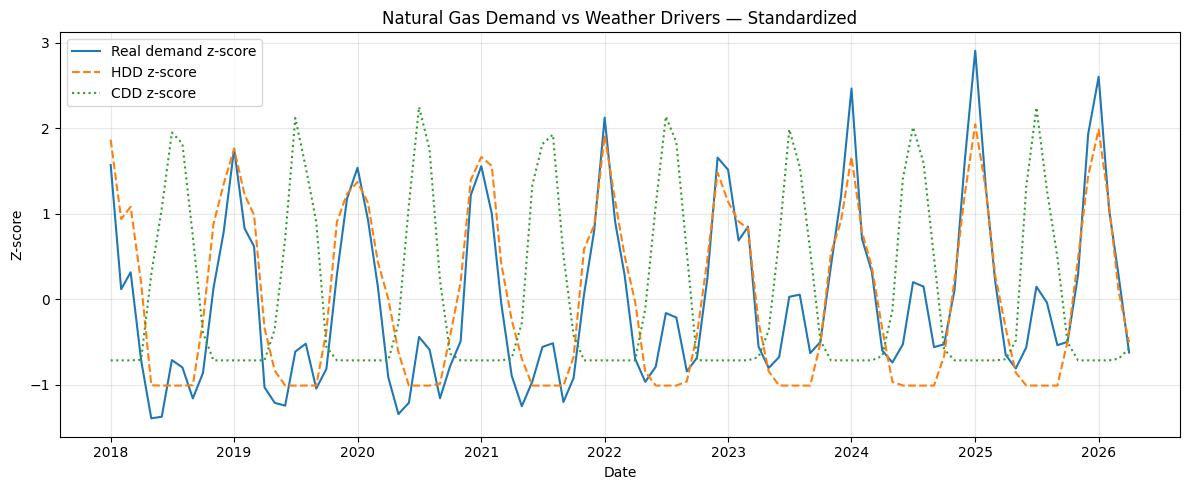

In [33]:
def plot_demand_vs_weather(monthly_with_weather):
    df = monthly_with_weather.copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    z_hdd = (df["hdd"] - df["hdd"].mean()) / df["hdd"].std(ddof=1)
    z_cdd = (df["cdd"] - df["cdd"].mean()) / df["cdd"].std(ddof=1)
    z_demand = (df["demand_bcf"] - df["demand_bcf"].mean()) / df["demand_bcf"].std(ddof=1)

    plt.figure(figsize=(12, 5))
    plt.plot(df.index, z_demand, label="Real demand z-score")
    plt.plot(df.index, z_hdd, linestyle="--", label="HDD z-score")
    plt.plot(df.index, z_cdd, linestyle=":", label="CDD z-score")
    plt.title("Natural Gas Demand vs Weather Drivers — Standardized")
    plt.xlabel("Date")
    plt.ylabel("Z-score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_demand_vs_weather(monthly_with_weather)

## 4. Scenario builders

These helper functions keep historical backtests, reporting charts, and forward Monte Carlo forecasts separate.


In [34]:
def make_backtest_scenario(base_scenario, panel_df):
    s = base_scenario.copy()

    # Historical weekly mode replays observed weekly storage and apportioned weekly flows.
    s["use_historical_drivers"] = True
    s["use_weather_demand"] = False
    s["historical_panel"] = panel_df.copy()
    s["initial_storage"] = float(panel_df["storage_bcf"].iloc[0])

    s["weather_mean"] = 0.0
    s["weather_volatility"] = 0.0
    s["weather_volatility_scale"] = 0.0
    s["demand_noise_bcf"] = 0.0
    s["supply_noise_pct"] = 0.0
    s["supply_noise_bcf"] = 0.0
    s["storage_response_factor"] = 0.95

    return s


def make_forward_scenario(
    base_scenario,
    *,
    initial_storage,
    lng_export_pct=0.0,
    demand_sigma=0.0,
    supply_pct=0.0,
    pipeline_capacity_pct=0.0,
    weather_volatility_scale=1.0,
):
    s = base_scenario.copy()

    s["use_historical_drivers"] = False
    s["use_weather_demand"] = True
    s.pop("historical_panel", None)

    s["initial_storage"] = float(initial_storage)
    s["lng_exports"] = float(s["lng_exports"] * (1.0 + lng_export_pct))
    s["base_demand"] = float(s["base_demand"] + demand_sigma * s.get("weather_volatility", 0.0))
    s["base_supply"] = float(s["base_supply"] * (1.0 + supply_pct))
    s["pipeline_capacity"] = float(s["pipeline_capacity"] * (1.0 + pipeline_capacity_pct))
    s["weather_volatility_scale"] = weather_volatility_scale

    s["storage_response_factor"] = 0.95
    s["demand_noise_bcf"] = 75.0
    s["supply_noise_pct"] = 0.01

    s["max_injection"] *= s.get("injection_pct", 0.9)
    s["max_withdrawal"] *= s.get("withdrawal_pct", 0.95)
    s["hdd_sensitivity_scale"] = float(s.get("hdd_sensitivity_scale", 0.95))
    s["cdd_sensitivity_scale"] = float(s.get("cdd_sensitivity_scale", 0.85))

    return s


def get_recent_window(df, rows=156):
    return df.tail(rows).copy()


## 5. Historical backtest

This tests whether the model captures broad historical storage and pressure behavior.

Do not overfit this section to one month. Use the full-period scores and charts.


In [35]:
# Historical weekly backtest uses actual weekly storage and Henry Hub,
# with production, demand, and LNG exports apportioned from monthly EIA totals.
backtest_panel = weekly_history_panel.copy()

backtest_scenario = make_backtest_scenario(base_scenario, backtest_panel)
best_simulated = simulate_weekly_historical_backtest(
    backtest_panel,
    backtest_scenario,
    price_model,
    initial_storage=float(backtest_panel["storage_bcf"].iloc[0]),
    initial_price=float(backtest_panel["henry_hub_price"].iloc[0]),
)
best_comparison = build_weekly_comparison(backtest_panel, best_simulated)

display(best_comparison[[
    "date",
    "price_real",
    "price_pressure_sim",
    "storage_real",
    "storage_start_bcf",
    "storage_end_sim",
    "storage_change_real",
    "storage_change_sim",
]].tail(12))


,date,price_real,price_pressure_sim,storage_real,storage_start_bcf,storage_end_sim,storage_change_real,storage_change_sim
423,2026-02-13,3.2700,0.500,2059.0,2612.0,2486.1,-143.0,-125.94
424,2026-02-20,3.0875,0.662,2007.0,2486.1,2360.2,-52.0,-125.94
425,2026-02-27,3.0140,0.500,1876.0,2360.2,2234.2,-131.0,-125.94
426,2026-03-06,2.9920,0.500,1838.0,2234.2,2223.2,-38.0,-11.07
427,2026-03-13,3.1900,0.500,1872.0,2223.2,2226.0,34.0,2.84
428,2026-03-20,3.1080,0.500,1818.0,2226.0,2228.8,-54.0,2.84
429,2026-03-27,2.9520,0.500,1851.0,2228.8,2231.7,33.0,2.84
430,2026-04-03,2.9025,0.500,1900.0,2231.7,2270.4,49.0,38.71
431,2026-04-10,2.8500,0.500,1960.0,2270.4,2322.9,60.0,52.45
432,2026-04-17,2.7700,0.686,2063.0,2322.9,2375.3,103.0,52.45


## 6. Backtest scoring

Useful diagnostics:
- Storage MAE — how close inventory path is
- Storage-change MAE — how close weekly builds/draws are
- Storage-change directional accuracy — whether the model gets build/draw direction right
- Historical price-pressure comparison remains diagnostic only and is not used in the forward forecast


In [36]:
def score_backtest(comparison):
    df = comparison.copy()

    df["storage_error"] = df["storage_end_sim"] - df["storage_real"]
    df["storage_change_error"] = df["storage_change_sim"] - df["storage_change_real"]

    storage_mae = df["storage_error"].abs().mean()
    storage_change_mae = df["storage_change_error"].abs().mean()

    valid_storage_change = df.dropna(subset=["storage_change_real", "storage_change_sim"])
    storage_direction_accuracy = (
        np.sign(valid_storage_change["storage_change_real"]) == np.sign(valid_storage_change["storage_change_sim"])
    ).mean()

    df["real_price_change"] = df["price_real"].diff()
    df["sim_pressure_change"] = df["price_pressure_sim"].diff()
    valid_price = df.dropna(subset=["real_price_change", "sim_pressure_change"])
    price_direction_accuracy = (
        np.sign(valid_price["real_price_change"]) == np.sign(valid_price["sim_pressure_change"])
    ).mean()

    return {
        "storage_mae_bcf": round(float(storage_mae), 1),
        "storage_change_mae_bcf": round(float(storage_change_mae), 1),
        "storage_change_direction_accuracy": round(float(storage_direction_accuracy), 3),
        "price_pressure_direction_accuracy": round(float(price_direction_accuracy), 3),
    }

score_backtest(best_comparison)


{'storage_mae_bcf': 326.9,
 'storage_change_mae_bcf': 31.1,
 'storage_change_direction_accuracy': 0.922,
 'price_pressure_direction_accuracy': 0.161}

## 7. Tune global pressure parameters

This grid search tunes only global pressure parameters.

It does **not** tune individual months. That keeps the model general enough for weekly monitoring.


In [37]:
enhanced_backtest_scores = score_weekly_comparison(best_comparison)
print("Weekly backtest scores:")
enhanced_backtest_scores


Weekly backtest scores:


{'storage_mae_bcf': 326.9,
 'storage_change_mae_bcf': 31.1,
 'price_mae': 2.647,
 'storage_change_direction_accuracy': 0.922,
 'price_direction_accuracy': 0.161}

## 8. Final historical monitor using best global parameters

This becomes the main historical dataframe used for weekly charts.


In [38]:
best_scenario = make_backtest_scenario(base_scenario, backtest_panel)
best_simulated = simulate_weekly_historical_backtest(
    backtest_panel,
    best_scenario,
    price_model,
    initial_storage=float(backtest_panel["storage_bcf"].iloc[0]),
    initial_price=float(backtest_panel["henry_hub_price"].iloc[0]),
)
best_comparison = build_weekly_comparison(backtest_panel, best_simulated)

enhanced_backtest_scores = score_weekly_comparison(best_comparison)
enhanced_backtest_scores


{'storage_mae_bcf': 326.9,
 'storage_change_mae_bcf': 31.1,
 'price_mae': 2.647,
 'storage_change_direction_accuracy': 0.922,
 'price_direction_accuracy': 0.161}

## 10. Reporting window

All monitor charts use the most recent `REPORT_LOOKBACK_WEEKS` weekly observations to keep the report readable.


## 9. Rolling-origin validation

This measures one- and three-month forecast quality using expanding training windows and the fitted price model.


In [39]:
rolling_validation = rolling_origin_validation_weekly(
    weekly_history_panel,
    train_min_weeks=104,
    horizons=(1, 4, 13),
)

rolling_validation_summary = (
    rolling_validation.groupby("horizon_weeks", as_index=False)
    .agg(
        avg_storage_mae_bcf=("storage_mae_bcf", "mean"),
        avg_storage_change_mae_bcf=("storage_change_mae_bcf", "mean"),
        avg_price_mae=("price_mae", "mean"),
        avg_storage_change_direction_accuracy=("storage_change_direction_accuracy", "mean"),
        avg_price_direction_accuracy=("price_direction_accuracy", "mean"),
    )
    .round(3)
)

display(rolling_validation_summary)
display(rolling_validation.tail())


,horizon_weeks,avg_storage_mae_bcf,avg_storage_change_mae_bcf,avg_price_mae,avg_storage_change_direction_accuracy,avg_price_direction_accuracy
0,1,31.355,31.353,1.840,0.912,NaN
1,4,58.602,30.805,2.481,0.915,0.276
2,13,116.483,30.007,2.900,0.915,0.161


,train_end_date,forecast_start_date,horizon_weeks,storage_mae_bcf,storage_change_mae_bcf,price_mae,storage_change_direction_accuracy,price_direction_accuracy
973,2026-01-02,2026-01-09,13,282.3,61.0,4.082,0.923,0.083
974,2026-01-09,2026-01-16,13,355.8,56.4,4.169,0.923,0.083
975,2026-01-16,2026-01-23,13,394.5,58.5,4.116,0.923,0.083
976,2026-01-23,2026-01-30,13,307.7,52.5,1.990,0.923,0.583
977,2026-01-30,2026-02-06,13,100.4,37.3,2.235,0.923,0.750


In [40]:
report_df = get_recent_window(best_comparison, rows=REPORT_LOOKBACK_WEEKS)

print("Report window:", report_df["date"].min().date(), "to", report_df["date"].max().date())
report_df.tail()


Report window: 2023-05-12 to 2026-05-01


,date,supply_real,demand_real,industrial_demand_bcf,lng_exports_real,storage_real,price_real,storage_change_real,hdd,cdd,...,delivered_supply_bcf,demand_sim,balance_bcf,storage_start_bcf,storage_end_sim,storage_change_sim,storage_ratio,pipeline_capacity_bcf,lng_exports_sim,total_demand_real
430,2026-04-03,775.875132,597.568868,149.392217,127.79089,1900.0,2.9025,49.0,48.825,3.00,...,766.11,725.36,40.75,2231.7,2270.4,38.71,0.576,766.11,127.79,725.359758
431,2026-04-10,776.454233,557.503100,139.375775,125.51840,1960.0,2.8500,60.0,62.250,0.00,...,766.11,683.02,83.09,2270.4,2322.9,52.45,0.590,766.11,125.52,683.021500
432,2026-04-17,776.454233,557.503100,139.375775,125.51840,2063.0,2.7700,103.0,7.050,21.48,...,766.11,683.02,83.09,2322.9,2375.3,52.45,0.603,766.11,125.52,683.021500
433,2026-04-24,776.454233,557.503100,139.375775,125.51840,2142.0,2.7020,79.0,35.010,0.48,...,766.11,683.02,83.09,2375.3,2427.7,52.45,0.616,766.11,125.52,683.021500
434,2026-05-01,665.532200,477.859800,119.464950,107.58720,2205.0,2.6580,63.0,55.950,0.00,...,665.53,585.45,80.09,2427.7,2503.8,76.08,0.636,766.11,107.59,585.447000


## 10. Weekly chart pack — storage and price pressure

Use these as your core weekly monitoring charts.


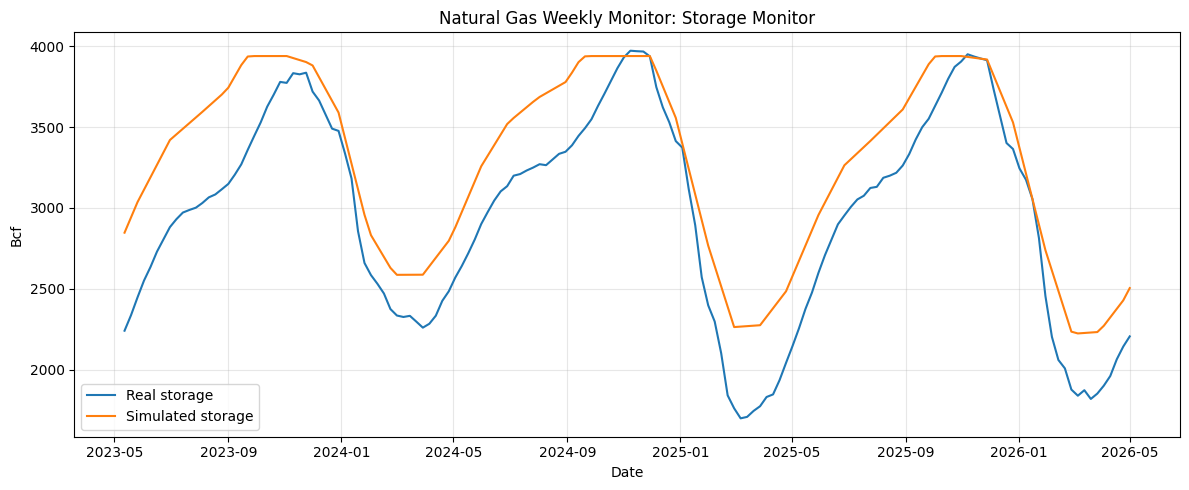

In [41]:
def plot_storage_monitor(report_df):
    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["storage_real"], label="Real storage")
    plt.plot(report_df["date"], report_df["storage_end_sim"], label="Simulated storage")
    plt.title(f"{REPORT_TITLE}: Storage Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_storage_monitor(report_df)


## 11. Weekly chart pack — supply, demand, and balance

Use these diagnostics to explain *why* storage or price pressure is changing.


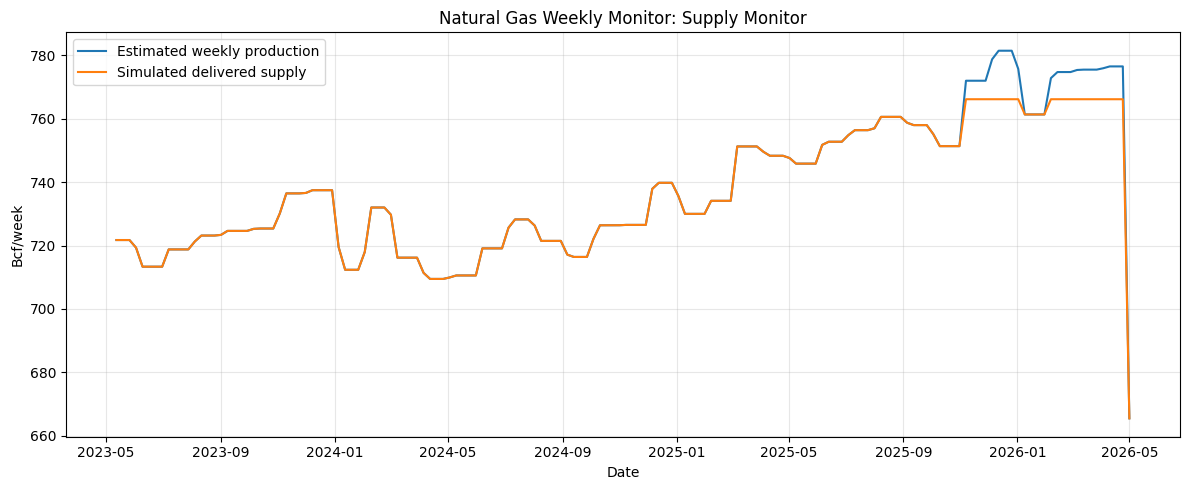

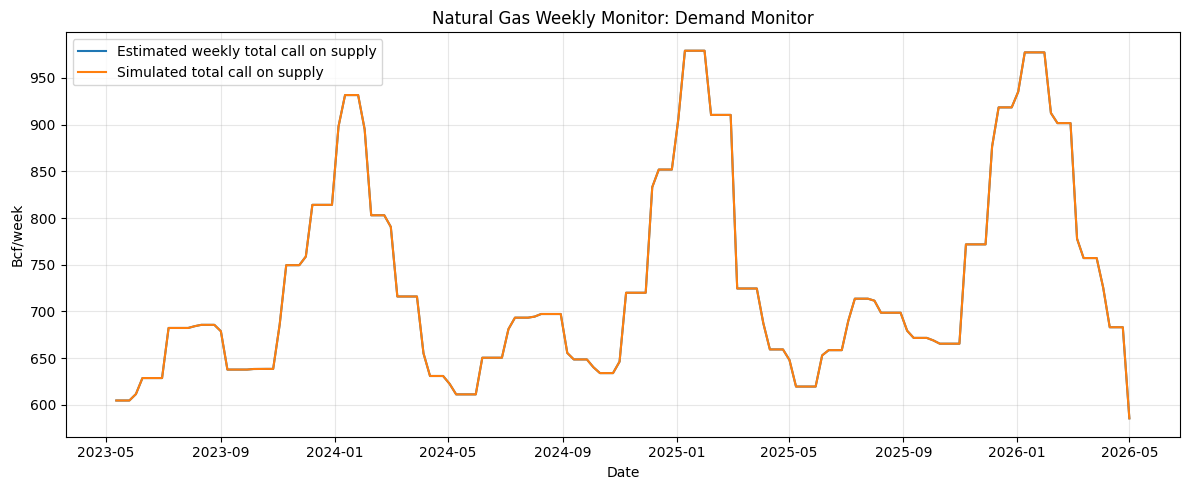

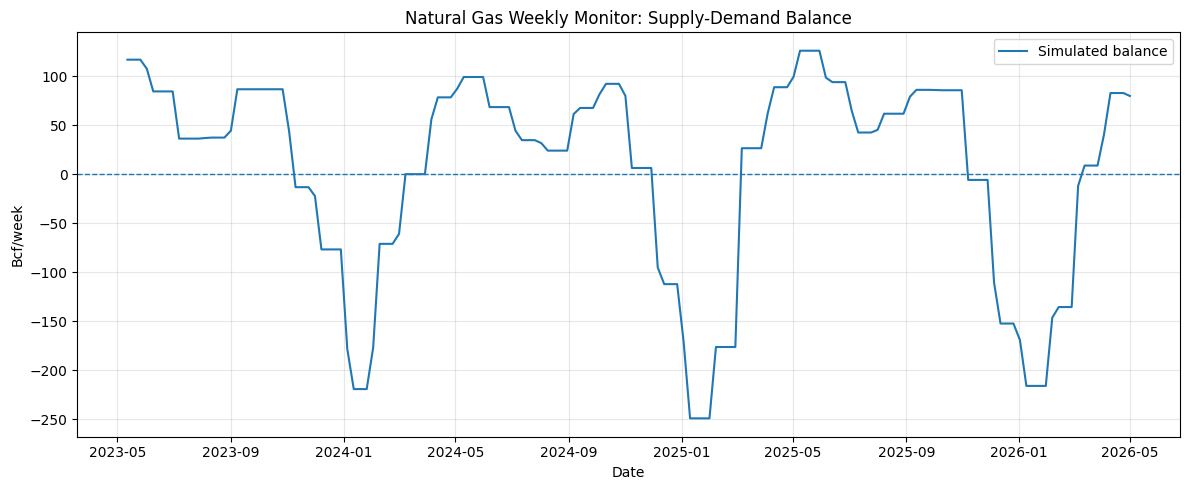

In [42]:
def plot_supply_demand_balance(report_df):
    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["supply_real"], label="Estimated weekly production")
    plt.plot(report_df["date"], report_df["delivered_supply_bcf"], label="Simulated delivered supply")
    plt.title(f"{REPORT_TITLE}: Supply Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf/week")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    real_demand_col = "total_demand_real" if "total_demand_real" in report_df.columns else "demand_real"
    if "demand_sim" in report_df.columns:
        sim_demand = report_df["demand_sim"]
    elif "demand_bcf_sim" in report_df.columns:
        sim_demand = report_df["demand_bcf_sim"]
    else:
        sim_demand = report_df["delivered_supply_bcf"] - report_df["balance_bcf"]
    plt.plot(report_df["date"], report_df[real_demand_col], label="Estimated weekly total call on supply")
    plt.plot(report_df["date"], sim_demand, label="Simulated total call on supply")
    plt.title(f"{REPORT_TITLE}: Demand Monitor")
    plt.xlabel("Date")
    plt.ylabel("Bcf/week")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(report_df["date"], report_df["balance_bcf"], label="Simulated balance")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title(f"{REPORT_TITLE}: Supply-Demand Balance")
    plt.xlabel("Date")
    plt.ylabel("Bcf/week")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_supply_demand_balance(report_df)


## 12. Pressure z-score and classification

This converts the pressure model into a reporting signal:

- Bullish / Bearish / Neutral
- Expected / Elevated / Extreme


In [43]:
def classify_pressure_z(z):
    if z >= 1.5:
        return "Extreme Bullish"
    if z >= 0.5:
        return "Bullish"
    if z <= -1.5:
        return "Extreme Bearish"
    if z <= -0.5:
        return "Bearish"
    return "Neutral"


def classify_extremeness(z):
    if abs(z) >= 1.5:
        return "Extreme"
    if abs(z) >= 0.5:
        return "Elevated"
    return "Expected"


def add_pressure_zscores(df, baseline=None, pressure_col="price_pressure_sim"):
    out = df.copy()
    if baseline is None:
        baseline = out[pressure_col]
    mu = float(pd.to_numeric(baseline, errors="coerce").mean())
    sigma = float(pd.to_numeric(baseline, errors="coerce").std(ddof=1))
    if sigma == 0 or not np.isfinite(sigma):
        sigma = 1.0
    out["pressure_z"] = (out[pressure_col] - mu) / sigma
    out["pressure_signal"] = out["pressure_z"].apply(classify_pressure_z)
    out["pressure_extremeness"] = out["pressure_z"].apply(classify_extremeness)
    return out

best_comparison = add_pressure_zscores(best_comparison, baseline=best_comparison["price_pressure_sim"])
report_df = get_recent_window(best_comparison, rows=REPORT_LOOKBACK_WEEKS)

report_df[["date", "price_real", "price_pressure_sim", "pressure_z", "pressure_signal", "pressure_extremeness"]].tail(12)


,date,price_real,price_pressure_sim,pressure_z,pressure_signal,pressure_extremeness
423,2026-02-13,3.2700,0.500,-0.366986,Neutral,Expected
424,2026-02-20,3.0875,0.662,-0.198732,Neutral,Expected
425,2026-02-27,3.0140,0.500,-0.366986,Neutral,Expected
426,2026-03-06,2.9920,0.500,-0.366986,Neutral,Expected
427,2026-03-13,3.1900,0.500,-0.366986,Neutral,Expected
428,2026-03-20,3.1080,0.500,-0.366986,Neutral,Expected
429,2026-03-27,2.9520,0.500,-0.366986,Neutral,Expected
430,2026-04-03,2.9025,0.500,-0.366986,Neutral,Expected
431,2026-04-10,2.8500,0.500,-0.366986,Neutral,Expected
432,2026-04-17,2.7700,0.686,-0.173805,Neutral,Expected


## 13. Next-quarter Monte Carlo forecast

The forward view now uses Monte Carlo simulation.

For each scenario, the notebook reports:
- Expected path
- Min / max path
- 10th / 90th percentile range

Use these outputs to frame next-quarter trend direction and whether conditions look expected, elevated, or extreme.


In [44]:
latest_monthly_market = report_df[["date", "price_real", "storage_real", "storage_change_real"]].iloc[[-1]].copy()
latest_monthly_market = latest_monthly_market.rename(columns={
    "date": "latest_monthly_date",
    "price_real": "latest_henry_hub_price",
    "storage_real": "latest_monthly_storage_bcf",
    "storage_change_real": "latest_monthly_storage_change_bcf",
})

latest_weekly_anchor = pd.DataFrame([
    {
        "latest_weekly_storage_release_date": latest_weekly_storage["release_date"],
        "latest_weekly_storage_bcf": latest_weekly_storage["storage_bcf"],
        "latest_weekly_storage_change_bcf": latest_weekly_storage["storage_change_bcf"],
    }
])

display(latest_monthly_market)
display(latest_weekly_anchor)


,latest_monthly_date,latest_henry_hub_price,latest_monthly_storage_bcf,latest_monthly_storage_change_bcf
434,2026-05-01,2.658,2205.0,63.0


,latest_weekly_storage_release_date,latest_weekly_storage_bcf,latest_weekly_storage_change_bcf
0,2026-06-26,2922.0,87.0


In [45]:
latest_storage = float(latest_weekly_storage["storage_bcf"])
latest_storage_release_date = pd.Timestamp(latest_weekly_storage["release_date"])

forward_scenarios = {
    "Base 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **BASE_FORWARD),
    "Cold + LNG 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **COLD_LNG_FORWARD),
    "Loose Supply 3M": make_forward_scenario(base_scenario, initial_storage=latest_storage, **LOOSE_SUPPLY_FORWARD),
}

for s in forward_scenarios.values():
    s["use_weather_demand"] = True
    s["initial_storage_release_date"] = latest_storage_release_date

forward_mc_results = pd.concat(
    [
        simulate_weekly_forward_scenario(
            name,
            scenario,
            monthly_with_weather,
            price_model,
            latest_weekly_storage,
            horizon_weeks=FORECAST_WEEKS,
            n_sims=N_MONTE_CARLO,
            seed=MC_SEED,
        )
        for name, scenario in forward_scenarios.items()
    ],
    ignore_index=True,
)

print("Monte Carlo storage dispersion by week:")
print(forward_mc_results.groupby(["scenario", "week"])["storage_bcf"].std().round(1))

forward_mc_results.head()

Monte Carlo storage dispersion by week:
scenario         week
Base 3M          1        3.8
                 2        5.2
                 3        6.4
                 4        7.2
                 5        7.9
                 6        8.2
                 7        8.3
                 8        8.6
                 9        8.7
                 10       8.8
                 11       9.0
                 12       9.0
                 13       9.1
Cold + LNG 3M    1       10.4
                 2       15.0
                 3       18.4
                 4       21.6
                 5       24.4
                 6       26.4
                 7       27.5
                 8       29.3
                 9       30.8
                 10      31.9
                 11      33.7
                 12      35.0
                 13      36.8
Loose Supply 3M  1        0.0
                 2        0.0
                 3        0.0
                 4        0.0
                 5        0.0
        

,scenario,simulation,week,forecast_date,raw_supply_bcf,delivered_supply_bcf,demand_bcf,domestic_demand_bcf,lng_exports_bcf,balance_bcf,storage_start_bcf,storage_bcf,storage_change_bcf,storage_ratio,hdd,cdd
0,Base 3M,0,1,2026-07-03,684.86,684.86,651.32,592.00,59.32,33.55,2922.0,2953.9,31.87,0.750,0.0,97.32
1,Base 3M,0,2,2026-07-10,698.57,698.57,628.95,569.63,59.32,69.62,2953.9,2991.4,37.55,0.759,0.0,99.60
2,Base 3M,0,3,2026-07-17,692.95,692.95,642.48,583.17,59.32,50.46,2991.4,3029.0,37.55,0.769,0.0,104.19
3,Base 3M,0,4,2026-07-24,691.95,691.95,638.04,578.72,59.32,53.91,3029.0,3066.5,37.55,0.779,0.0,108.01
4,Base 3M,0,5,2026-07-31,697.44,697.44,645.65,586.33,59.32,51.80,3066.5,3104.1,37.55,0.788,0.0,104.19


## 14. Monte Carlo expected, min, max summary

This is the table to use for the next-quarter report.


In [46]:
forward_mc_summary = summarize_weekly_monte_carlo(forward_mc_results)
forward_mc_summary


,scenario,week,forecast_date,expected_storage_bcf,min_storage_bcf,max_storage_bcf,p10_storage_bcf,p90_storage_bcf,expected_storage_change_bcf,min_storage_change_bcf,max_storage_change_bcf,expected_balance_bcf,min_balance_bcf,max_balance_bcf
0,Base 3M,1,2026-07-03,2957.96,2934.8,2959.6,2953.19,2959.60,35.92,12.75,37.55,46.75,13.42,78.40
1,Base 3M,2,2026-07-10,2994.06,2960.5,2997.1,2986.29,2997.10,36.14,18.41,37.55,47.27,19.38,75.65
2,Base 3M,3,2026-07-17,3030.20,2986.2,3034.7,3020.78,3034.70,36.11,16.83,37.55,47.06,17.71,77.49
3,Base 3M,4,2026-07-24,3066.14,3023.7,3072.2,3056.08,3072.20,35.96,14.49,37.55,46.64,15.26,82.11
4,Base 3M,5,2026-07-31,3102.39,3061.3,3109.8,3091.89,3109.80,36.24,17.25,37.55,47.63,18.16,79.82
5,Base 3M,6,2026-08-07,3140.99,3100.3,3148.8,3129.48,3148.80,38.61,24.08,39.03,54.70,25.35,90.84
6,Base 3M,7,2026-08-14,3179.64,3139.4,3187.8,3167.50,3187.80,38.66,12.70,39.03,55.88,13.37,87.41
7,Base 3M,8,2026-08-21,3218.07,3178.4,3226.8,3205.48,3226.80,38.43,21.73,39.03,54.94,22.87,87.46
8,Base 3M,9,2026-08-28,3256.68,3217.4,3265.9,3243.87,3265.90,38.60,22.05,39.03,55.31,23.21,87.03
9,Base 3M,10,2026-09-04,3326.52,3287.4,3335.9,3312.99,3335.90,69.83,55.70,69.99,92.98,58.63,121.59


## 15. Next-quarter Monte Carlo charts

Use the expected line as the base case and the min/max or 10–90% band to show uncertainty.


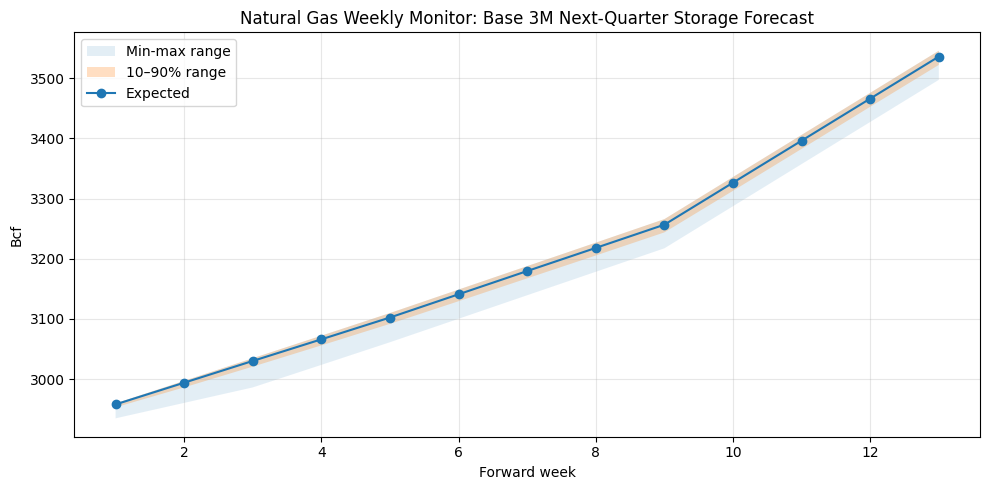

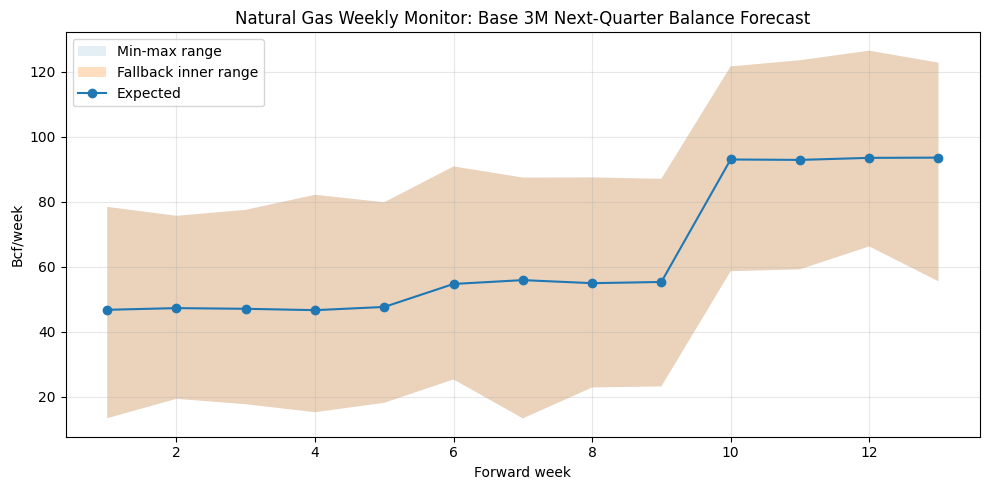

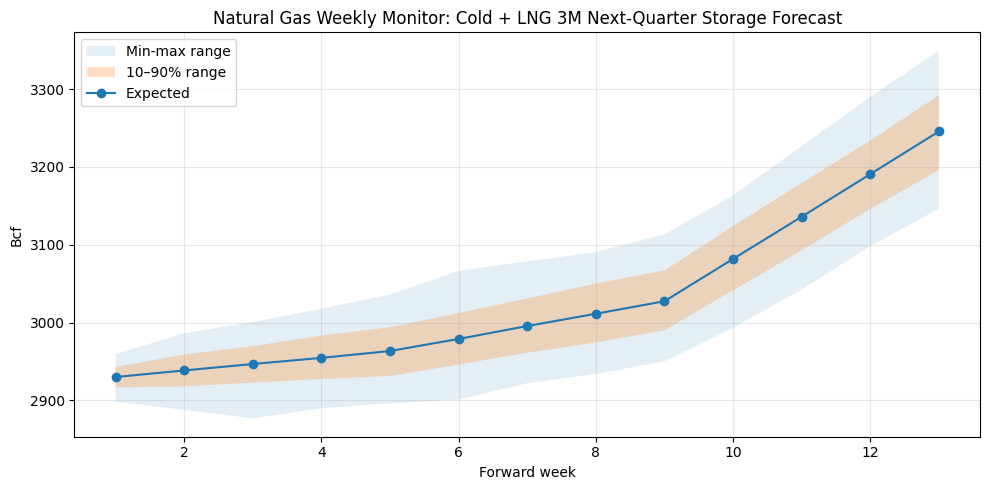

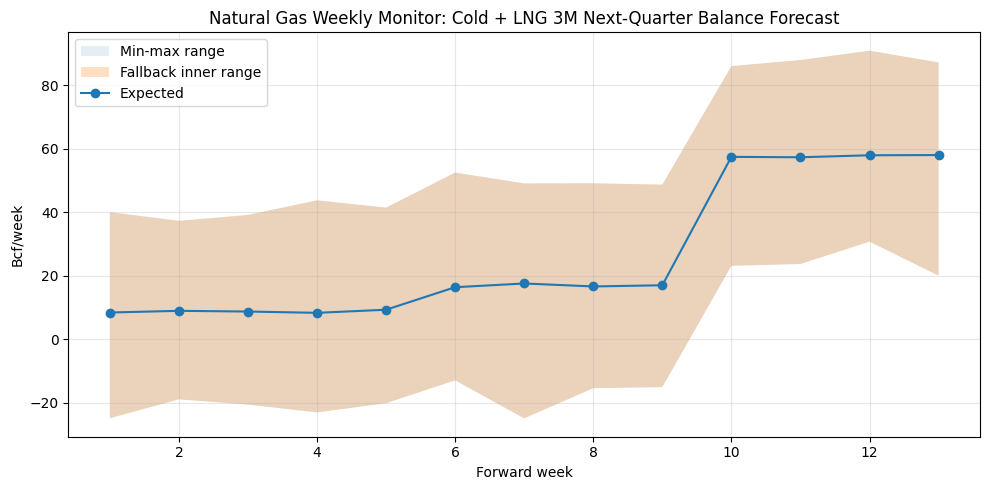

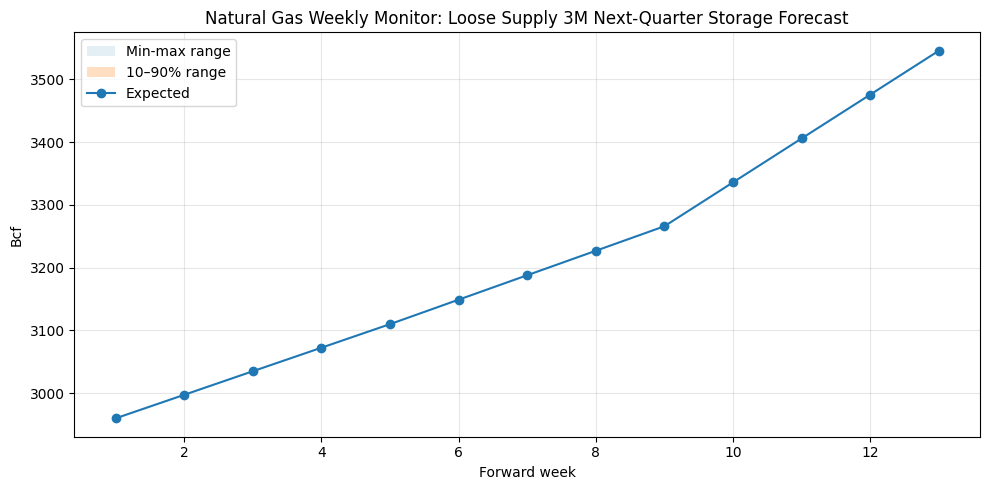

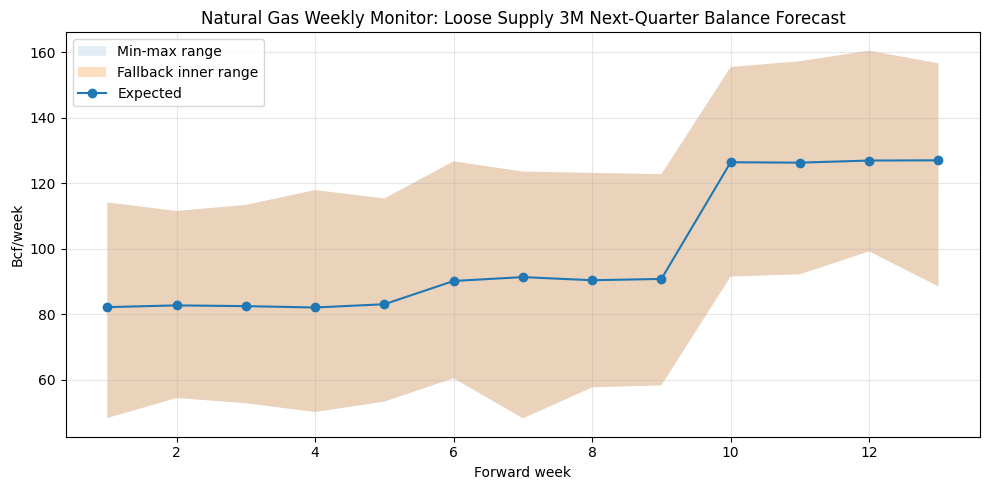

In [48]:
def plot_mc_band(summary, scenario, value_prefix, ylabel, title):
    g = summary[summary["scenario"] == scenario].copy().sort_values("week")
    x = g["week"].to_numpy(dtype=float)
    expected = g[f"expected_{value_prefix}"].to_numpy(dtype=float)

    p10_col = f"p10_{value_prefix}"
    p90_col = f"p90_{value_prefix}"
    min_col = f"min_{value_prefix}"
    max_col = f"max_{value_prefix}"

    if p10_col in g.columns and p90_col in g.columns:
        p10 = g[p10_col].to_numpy(dtype=float)
        p90 = g[p90_col].to_numpy(dtype=float)
    else:
        p10 = g[min_col].to_numpy(dtype=float)
        p90 = g[max_col].to_numpy(dtype=float)

    vmin = g[min_col].to_numpy(dtype=float)
    vmax = g[max_col].to_numpy(dtype=float)

    plt.figure(figsize=(10, 5))
    plt.fill_between(x, vmin, vmax, alpha=0.12, label="Min-max range")
    plt.fill_between(x, p10, p90, alpha=0.25, label="10–90% range" if p10_col in g.columns else "Fallback inner range")
    plt.plot(x, expected, marker="o", label="Expected")
    plt.title(title)
    plt.xlabel("Forward week")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


for scenario in forward_mc_summary["scenario"].unique():
    plot_mc_band(
        forward_mc_summary,
        scenario,
        value_prefix="storage_bcf",
        ylabel="Bcf",
        title=f"{REPORT_TITLE}: {scenario} Next-Quarter Storage Forecast",
    )

    plot_mc_band(
        forward_mc_summary,
        scenario,
        value_prefix="balance_bcf",
        ylabel="Bcf/week",
        title=f"{REPORT_TITLE}: {scenario} Next-Quarter Balance Forecast",
    )


## 16. Forward signal table

This converts Monte Carlo output into an Energy Atlas-style signal.

The signal uses expected storage change, ending storage range, average balance, and uncertainty range.


In [49]:
forward_signals = build_weekly_market_signal(forward_mc_summary)
forward_signals


,scenario,horizon_weeks,horizon_months,market_regime,extremeness,storage_trend,expected_storage_change_bcf,expected_ending_storage_bcf,p10_ending_storage_bcf,p90_ending_storage_bcf,min_ending_storage_bcf,max_ending_storage_bcf,expected_avg_balance_bcf,confidence
1,Cold + LNG 3M,13,3.0,Loose,Elevated,Loosening,323.5,3245.5,3195.9,3292.0,3146.3,3349.3,26.3,0.95
0,Base 3M,13,3.0,Loose,Extreme,Loosening,614.1,3536.1,3522.3,3545.8,3497.4,3545.8,63.8,0.95
2,Loose Supply 3M,13,3.0,Loose,Extreme,Loosening,623.8,3545.8,3545.8,3545.8,3545.8,3545.8,98.6,0.95


## 17. Weekly report summary

This cell prints a draft text block you can use for Energy Atlas, Twitter/X, or Substack.


In [50]:
def format_energy_atlas_signal(signal):
    return (
        f"{signal['scenario']} ({signal['horizon_months']}M): "
        f"{signal['market_regime']} market regime, {signal['extremeness'].lower()} conditions. "
        f"Expected storage path is {signal['storage_trend'].lower()} "
        f"({signal['expected_storage_change_bcf']} Bcf over the horizon). "
        f"Expected ending storage: {signal['expected_ending_storage_bcf']} Bcf "
        f"(p10-p90: {signal['p10_ending_storage_bcf']}–{signal['p90_ending_storage_bcf']} Bcf; "
        f"min-max: {signal['min_ending_storage_bcf']}–{signal['max_ending_storage_bcf']} Bcf). "
        f"Expected average weekly balance: {signal['expected_avg_balance_bcf']} Bcf/week. "
        f"Confidence: {signal['confidence']:.2f}."
    )


latest = report_df.iloc[-1]
prior = report_df.iloc[-2] if len(report_df) > 1 else latest

print(f"# {REPORT_TITLE} — {REPORT_DATE.date()}")
print()
print("## Current market read")
print(
    f"Latest weekly model point is {latest['storage_real']:,.0f} Bcf. "
    f"The latest weekly storage change was {latest['storage_change_real']:,.0f} Bcf."
)
print(
    f"Forward forecast anchor: weekly EIA storage release on {latest_weekly_storage['release_date'].date()} "
    f"at {latest_weekly_storage['storage_bcf']:,.0f} Bcf."
)

print()
print("## Next-quarter Monte Carlo scenarios")
for row in forward_signals.to_dict("records"):
    print("- " + format_energy_atlas_signal(row))

print()
print("## Suggested framing")
print(
    "The model should be interpreted as a physical market regime monitor, not a Henry Hub forecast. "
    "The key question is whether storage and balance conditions point to tightening, loosening, or normal seasonal behavior over the next quarter."
)


# Natural Gas Weekly Monitor — 2026-07-05

## Current market read
Latest weekly model point is 2,205 Bcf. The latest weekly storage change was 63 Bcf.
Forward forecast anchor: weekly EIA storage release on 2026-06-26 at 2,922 Bcf.

## Next-quarter Monte Carlo scenarios
- Cold + LNG 3M (3.0M): Loose market regime, elevated conditions. Expected storage path is loosening (323.5 Bcf over the horizon). Expected ending storage: 3245.5 Bcf (p10-p90: 3195.9–3292.0 Bcf; min-max: 3146.3–3349.3 Bcf). Expected average weekly balance: 26.3 Bcf/week. Confidence: 0.95.
- Base 3M (3.0M): Loose market regime, extreme conditions. Expected storage path is loosening (614.1 Bcf over the horizon). Expected ending storage: 3536.1 Bcf (p10-p90: 3522.3–3545.8 Bcf; min-max: 3497.4–3545.8 Bcf). Expected average weekly balance: 63.8 Bcf/week. Confidence: 0.95.
- Loose Supply 3M (3.0M): Loose market regime, extreme conditions. Expected storage path is loosening (623.8 Bcf over the horizon). Expected ending storage

## 18. Optional export

Set `EXPORT = True` if you want CSV outputs for charting or uploading elsewhere.


In [51]:
EXPORT = False

if EXPORT:
    report_df.to_csv("energy_atlas_weekly_monitor_history.csv", index=False)
    forward_mc_results.to_csv("energy_atlas_forward_monte_carlo_paths.csv", index=False)
    forward_mc_summary.to_csv("energy_atlas_forward_monte_carlo_summary.csv", index=False)
    forward_signals.to_csv("energy_atlas_forward_signals.csv", index=False)
    print("Exported weekly monitor and forward Monte Carlo CSV files.")
